# Notebook 4 - BERT4Rec + Actor-Critic Rerank + SIDE-FEATURES + Diversity

Self-contained (chi import `Bert4Rec_model`). BERT dong bang -> top-50 (loai phim da xem) -> Actor-Critic sap lai, **dung them feature BERT KHONG co**: genre, nam, popularity, demographic (gioi tinh/tuoi/nghe). Reward = relevance(NDCG rating) + lam*diversity(ILD). Actor init=BERT (san >= BERT). Baseline & RL **cung loc history** (cong bang).
Metrics: DCG/NDCG/Recall (nhu cu) + **ILD@10 (da dang) + Coverage@10 + Novelty@10**.

In [1]:
import os, sys, json, math, random, re
import numpy as np, pandas as pd, torch
import torch.nn as nn, torch.nn.functional as F, torch.optim as optim
import matplotlib.pyplot as plt
HERE = os.path.abspath("bert_ac_longterm") if os.path.isdir("bert_ac_longterm") else os.getcwd()
ROOT = os.path.dirname(HERE); sys.path.insert(0, ROOT)
from Bert4Rec_model import BERT4Rec, gather_indexes   # CHI import file model goc
import wandb
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MAX_LEN = 200
DATA = os.path.join(ROOT, "Data_Movielens_1m", "ml-1m")
RATING_FILE = os.path.join(DATA, "ratings.dat")
MOVIES_FILE = os.path.join(DATA, "movies.dat")
USERS_FILE  = os.path.join(DATA, "users.dat")
ENV_FILE    = os.path.join(ROOT, ".env")
def set_seed(s=42):
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic = True; torch.backends.cudnn.benchmark = False
set_seed(42)
def load_env_key(p, key="wandb_api_key"):
    if not os.path.exists(p): return None
    for line in open(p, encoding="utf-8"):
        if "=" in line:
            k, v = line.split("=", 1)
            if k.strip() == key: return v.strip()
    return None
print("Device:", DEVICE)

Device: cuda


## Helpers + side-info (genre/year/pop/demo) + metrics moi

In [2]:
GENRES = ["Action","Adventure","Animation","Children's","Comedy","Crime","Documentary",
          "Drama","Fantasy","Film-Noir","Horror","Musical","Mystery","Romance","Sci-Fi",
          "Thriller","War","Western"]
G2I = {g:i for i,g in enumerate(GENRES)}

def load_all(rating_file, movies_file, users_file, test_frac=0.2, min_len=5, max_len=MAX_LEN):
    cols=["UserID","MovieID","Rating","Timestamp"]
    df=pd.read_csv(rating_file,sep="::",engine="python",names=cols)
    df=df.sort_values(["UserID","Timestamp"]).reset_index(drop=True)
    raw=sorted(df["MovieID"].unique()); m2i={m:i+1 for i,m in enumerate(raw)}; n_items=len(raw)
    df["enc"]=df["MovieID"].map(m2i); df["pair"]=list(zip(df["enc"],df["Rating"].astype(float)))
    seqs=df.groupby("UserID")["pair"].apply(list).to_dict()
    # genre + year (movies.dat) -> theo enc id  (metadata tinh, KHONG leak)
    genre=np.zeros((n_items+1,len(GENRES)),dtype=np.float32); year=np.zeros(n_items+1,dtype=np.float32)
    mv=pd.read_csv(movies_file,sep="::",engine="python",names=["MovieID","Title","Genres"],encoding="latin-1")
    for _,r in mv.iterrows():
        e=m2i.get(r["MovieID"]);
        if e is None: continue
        for g in str(r["Genres"]).split("|"):
            if g in G2I: genre[e,G2I[g]]=1.0
        mt=re.search(r"\((\d{4})\)",str(r["Title"])); year[e]=(int(mt.group(1))-1900)/100.0 if mt else 0.9
    # user demographic (users.dat)
    ud={}
    uu=pd.read_csv(users_file,sep="::",engine="python",names=["UserID","Gender","Age","Occupation","Zip"],encoding="latin-1")
    for _,r in uu.iterrows():
        ud[int(r["UserID"])]=[1.0 if r["Gender"]=="M" else 0.0, float(r["Age"])/56.0, float(r["Occupation"])/20.0]
    # split + popularity CHI tu TRAIN (remaining) -> KHONG leak test
    pop=np.zeros(n_items+1,dtype=np.float64)
    users=[]; ni=nt=nr=0
    for uid,seq in seqs.items():
        if len(seq)<min_len: continue
        n=len(seq); ts=max(1,round(test_frac*n)); rem=seq[:-ts]; test=seq[-ts:]
        if len(rem)<2: continue
        for m,_r in rem: pop[int(m)]+=1                          # dem popularity CHI tren train
        rs=max(1,round(test_frac*len(rem))); rh=rem[:-rs]; rr=rem[-rs:]
        if len(rh)<1: rh=rem[:1]; rr=rem[1:] or rem[-1:]
        ri=[m for m,r in rem][-max_len:]
        users.append({"uid":int(uid),"hist_items":ri,"test_rel":{int(m):float(r) for m,r in test},
                      "rl_hist_items":[m for m,r in rh][-max_len:],"rl_rel":{int(m):float(r) for m,r in rr},
                      "demo":ud.get(int(uid),[0.5,0.5,0.5])})
        ni+=n; nt+=len(test); nr+=len(rem)
    pop_prob=pop/max(1.0,pop.sum()); pop_prob[0]=1.0              # cho Novelty (train-only)
    pop_feat=np.log1p(pop); pop_feat=pop_feat/max(1e-6,pop_feat.max())   # feature (train-only)
    stats={"n_users":len(users),"n_items":n_items,"n_interactions":int(ni),"n_train_remaining":int(nr),
           "n_test":int(nt),"avg_seq_len":round(ni/max(1,len(users)),2),
           "avg_test_len":round(nt/max(1,len(users)),2),"test_frac":test_frac,"max_len":max_len}
    return users, n_items, m2i, stats, genre, year, pop_feat, pop_prob

@torch.no_grad()
def encode_states(bert, hist_list, max_len=MAX_LEN, bs=256):
    bert.eval(); outs=[]
    for i in range(0,len(hist_list),bs):
        chunk=hist_list[i:i+bs]; b=len(chunk)
        item_seq=torch.zeros((b,max_len),dtype=torch.long,device=DEVICE); slen=torch.zeros((b,),dtype=torch.long,device=DEVICE)
        for j,s in enumerate(chunk):
            L=min(len(s),max_len); slen[j]=max(L,1)
            if L>0: item_seq[j,:L]=torch.tensor(s[-L:],dtype=torch.long,device=DEVICE)
        so=bert.forward(bert.reconstruct_test_data(item_seq,slen)); outs.append(gather_indexes(so,slen-1))
    return torch.cat(outs,0)

# ---- Metrics: accuracy (graded rating) + ILD/Coverage/Novelty ----
def dcg_at_k(r,rel,k):
    s=0.0
    for i,it in enumerate(r[:k]):
        g=rel.get(int(it),0.0)
        if g>0: s+=(2.0**g-1.0)/math.log2(i+2)
    return s
def ndcg_at_k(r,rel,k):
    ideal=sorted(rel.values(),reverse=True); idcg=sum((2.0**g-1.0)/math.log2(i+2) for i,g in enumerate(ideal[:k]))
    return dcg_at_k(r,rel,k)/idcg if idcg>0 else 0.0
def recall_at_k(r,rel,k):
    return (sum(1 for it in r[:k] if int(it) in rel)/len(rel)) if rel else 0.0
def ild_at_k(r,genre_norm,k):
    ids=[int(x) for x in r[:k]]
    if len(ids)<2: return 0.0
    G=genre_norm[ids]; sim=G@G.T; n=len(ids); off=(sim.sum()-np.trace(sim))/(n*(n-1))
    return float(1.0-off)
def metrics_full(ranks, rels, genre, pop_prob, ks=(5,10,20)):
    gn=genre/np.clip(np.linalg.norm(genre,axis=1,keepdims=True),1e-6,None)   # chuan hoa genre cho cosine
    m={}
    for k in ks:
        m[f"DCG@{k}"]=float(np.mean([dcg_at_k(r,rl,k) for r,rl in zip(ranks,rels)]))
        m[f"NDCG@{k}"]=float(np.mean([ndcg_at_k(r,rl,k) for r,rl in zip(ranks,rels)]))
        m[f"Recall@{k}"]=float(np.mean([recall_at_k(r,rl,k) for r,rl in zip(ranks,rels)]))
    m["ILD@10"]=float(np.mean([ild_at_k(r,gn,10) for r in ranks]))
    seen=set();
    for r in ranks: seen.update(int(x) for x in r[:10])
    m["Coverage@10"]=len(seen)/ (genre.shape[0]-1)
    m["Novelty@10"]=float(np.mean([np.mean([-math.log2(max(pop_prob[int(x)],1e-9)) for x in r[:10]]) for r in ranks]))
    return m
print("[+] helpers + side-info ready (popularity TRAIN-ONLY, het leak)")

[+] helpers + side-info ready (popularity TRAIN-ONLY, het leak)


## 1. Load data + side-info + BERT (NB1) dong bang

In [3]:
users, n_real, movie2id, stats, GENRE_np, YEAR_np, POPF_np, POPPROB_np = load_all(RATING_FILE, MOVIES_FILE, USERS_FILE)
n_model = n_real + 1
json.dump(stats, open(os.path.join(HERE,"data_stats.json"),"w"), ensure_ascii=False, indent=2)
print(json.dumps(stats, ensure_ascii=False, indent=2))
bert=BERT4Rec(n_items=n_model, max_seq_length=MAX_LEN, hidden_size=64, n_layers=2, n_heads=2,
              hidden_dropout_prob=0.2, attn_dropout_prob=0.2, loss_type="CE").to(DEVICE)
bert.load_state_dict(torch.load(os.path.join(HERE,"bert4rec.pth"), map_location=DEVICE)); bert.eval()
for p in bert.parameters(): p.requires_grad=False
# tensor side-info tren device
GENRE=torch.tensor(GENRE_np,device=DEVICE); YEAR=torch.tensor(YEAR_np,device=DEVICE).unsqueeze(-1)
POPF=torch.tensor(POPF_np,device=DEVICE,dtype=torch.float32).unsqueeze(-1)
ITEM_EMB=bert.item_embedding.weight[:bert.n_items].detach(); BIAS=bert.output_bias.detach()
print("BERT frozen + side-info tensors ready | genre dim", GENRE.shape[1])

{
  "n_users": 6040,
  "n_items": 3706,
  "n_interactions": 1000209,
  "n_train_remaining": 800193,
  "n_test": 200016,
  "avg_seq_len": 165.6,
  "avg_test_len": 33.12,
  "test_frac": 0.2,
  "max_len": 200
}
BERT frozen + side-info tensors ready | genre dim 18


C:\Users\TanPhat\AppData\Local\Temp\ipykernel_41676\1327405972.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  bert.load_state_dict(torch.load(os.path.join(HERE,"bert4re

## 2. Rankers (baseline & AC cung loc history) + feature builder

In [4]:
@torch.no_grad()
def rank_bert(bert, users, target="test", subset=None, K=20):
    hk="hist_items" if target=="test" else "rl_hist_items"; rk="test_rel" if target=="test" else "rl_rel"
    idx=list(range(len(users))) if subset is None else subset
    S=encode_states(bert,[users[i][hk] for i in idx]); ranks=[]
    for i in range(0,S.shape[0],256):
        chunk=idx[i:i+256]; sc=S[i:i+256]@ITEM_EMB.T+BIAS; sc[:,0]=-1e9
        for j,u in enumerate(chunk): sc[j,users[u][hk]]=-1e9     # loai phim da xem (cong bang)
        ranks+=torch.topk(sc,K,1).indices.cpu().numpy().tolist()
    return ranks,[users[i][rk] for i in idx]

def cand_feats(cand_ids, cand_logit, demo):
    g=GENRE[cand_ids]; y=YEAR[cand_ids]; p=POPF[cand_ids]                # [B,N,18],[B,N,1],[B,N,1]
    mu=cand_logit.mean(1,keepdim=True); sd=cand_logit.std(1,keepdim=True).clamp(min=1e-6)
    lg=((cand_logit-mu)/sd).unsqueeze(-1)                                # [B,N,1]
    d=demo.unsqueeze(1).expand(-1,cand_ids.shape[1],-1)                  # [B,N,3]
    return torch.cat([g,y,p,lg,d],-1)                                    # [B,N,18+1+1+1+3=24]

## 3. Actor-Critic + side-features + diversity reward

In [5]:
# ====== ACTOR-CRITIC RERANK + SIDE-FEATURES (genre/year/pop/demo) ======
# Actor: score = bert_logit + beta*delta([state, cand_emb, bert_logit_norm, genre,year,pop, demo])
# init lop cuoi = 0 -> delta=0 -> thu tu khoi dau = BERT (san >= BERT).
SIDE_DIM = 18 + 1 + 1 + 1 + 3   # genre+year+pop+logit_norm+demo = 24
class Actor(nn.Module):
    def __init__(self, dim, side_dim, beta=1.0):
        super().__init__(); self.beta=beta
        self.net=nn.Sequential(nn.Linear(2*dim+side_dim,256),nn.ReLU(),nn.Linear(256,64),nn.ReLU(),nn.Linear(64,1))
        nn.init.zeros_(self.net[-1].weight); nn.init.zeros_(self.net[-1].bias)
    def forward(self, state, cand_emb, cand_ids, cand_logit, demo):
        B,N,H=cand_emb.shape; s=state.unsqueeze(1).expand(-1,N,-1)
        feat=cand_feats(cand_ids, cand_logit, demo)                      # [B,N,24]
        x=torch.cat([s,cand_emb,feat],-1)
        delta=self.net(x).squeeze(-1)
        return cand_logit + self.beta*delta

class Critic(nn.Module):
    def __init__(self, dim):
        super().__init__(); self.net=nn.Sequential(nn.Linear(dim,128),nn.ReLU(),nn.Linear(128,1))
    def forward(self, state): return self.net(state).squeeze(-1)

@torch.no_grad()
def bert_topN(st, hists, topN):
    sc=st@ITEM_EMB.T+BIAS; sc[:,0]=-1e9
    for j,h in enumerate(hists): sc[j,h]=-1e9                            # loai phim da xem
    top=torch.topk(sc,topN,1)
    return top.indices, ITEM_EMB[top.indices], top.values

def cand_gain(cand_ids, rels):
    B,N=cand_ids.shape; g=np.zeros((B,N),dtype=np.float32); cid=cand_ids.cpu().numpy()
    for b in range(B):
        rel=rels[b]
        if not rel: continue
        for j in range(N):
            r=rel.get(int(cid[b,j]),0.0)
            if r>0: g[b,j]=2.0**r-1.0
    return torch.tensor(g,device=cand_ids.device)

@torch.no_grad()
def rank_ac(bert, actor, users, target="test", subset=None, topN=50, K=20):
    hk="hist_items" if target=="test" else "rl_hist_items"; rk="test_rel" if target=="test" else "rl_rel"
    idx=list(range(len(users))) if subset is None else subset
    S=encode_states(bert,[users[i][hk] for i in idx]); ranks=[]
    for i in range(0,S.shape[0],256):
        chunk=idx[i:i+256]; st=S[i:i+256]; hists=[users[u][hk] for u in chunk]
        demo=torch.tensor([users[u]["demo"] for u in chunk],device=DEVICE,dtype=torch.float32)
        cand_ids,cand_emb,cand_logit=bert_topN(st,hists,topN)
        order=torch.argsort(actor(st,cand_emb,cand_ids,cand_logit,demo),1,descending=True)
        ranks+=torch.gather(cand_ids,1,order).cpu().numpy().tolist()
    return ranks,[users[i][rk] for i in idx]

def val_dcg10(bert, actor, users, subset, topN=50):
    rk,rl=rank_ac(bert,actor,users,target="rl",subset=subset,topN=topN,K=10)
    return float(np.mean([dcg_at_k(r,x,10) for r,x in zip(rk,rl)]))

def train_ac(bert, users, epochs=30, bs=256, topN=50, K=10, lr=1e-4, lam=0.3, patience=8, run=None):
    dim=bert.hidden_size
    actor=Actor(dim,SIDE_DIM).to(DEVICE); critic=Critic(dim).to(DEVICE)
    aopt=optim.Adam(actor.parameters(),lr); copt=optim.Adam(critic.parameters(),lr)
    disc=(1.0/torch.log2(torch.arange(K,device=DEVICE).float()+2)).unsqueeze(0)
    GN=F.normalize(GENRE,p=2,dim=-1)                                     # cho diversity
    rl_rel=[u["rl_rel"] for u in users]
    S=encode_states(bert,[u["rl_hist_items"] for u in users]).cpu(); N=S.shape[0]
    demo_all=torch.tensor([u["demo"] for u in users],dtype=torch.float32)
    hists_all=[u["rl_hist_items"] for u in users]
    val_sub=list(range(0,N,max(1,N//2000)))[:2000]
    hist={"actor":[],"critic":[],"reward":[],"val_dcg10":[]}
    base=val_dcg10(bert,actor,users,val_sub,topN); print(f"[AC+feat] VAL DCG@10 init(=BERT)={base:.4f}")
    best,best_sd,noimp=base,{k:v.detach().clone() for k,v in actor.state_dict().items()},0
    for ep in range(epochs):
        actor.train(); critic.train(); perm=np.random.permutation(N); ea=ec=er=0.0; nb=0
        for i in range(0,N,bs):
            bidx=perm[i:i+bs]; st=S[bidx].to(DEVICE); rels=[rl_rel[j] for j in bidx]
            demo=demo_all[bidx].to(DEVICE); hists=[hists_all[j] for j in bidx]
            cand_ids,cand_emb,cand_logit=bert_topN(st,hists,topN)
            gains=cand_gain(cand_ids,rels); scores=actor(st,cand_emb,cand_ids,cand_logit,demo)
            avail=torch.ones_like(scores,dtype=torch.bool); logp=torch.zeros(scores.shape[0],device=DEVICE)
            cgain=torch.zeros(scores.shape[0],K,device=DEVICE); chosen=torch.zeros(scores.shape[0],K,dtype=torch.long,device=DEVICE)
            for t in range(K):
                m=torch.distributions.Categorical(F.softmax(scores.masked_fill(~avail,-1e9),-1))
                a=m.sample(); logp=logp+m.log_prob(a)
                cgain[:,t]=gains.gather(1,a.unsqueeze(1)).squeeze(1)
                chosen[:,t]=cand_ids.gather(1,a.unsqueeze(1)).squeeze(1)
                avail.scatter_(1,a.unsqueeze(1),False)
            dcg=(cgain*disc).sum(1); ideal,_=torch.sort(gains,1,descending=True)
            idcg=(ideal[:,:K]*disc).sum(1).clamp(min=1e-8); rel_r=dcg/idcg
            # diversity: 1 - do giong genre trung binh trong slate
            gsel=GN[chosen]; sim=torch.bmm(gsel,gsel.transpose(1,2))
            offsum=sim.sum((1,2))-torch.diagonal(sim,dim1=1,dim2=2).sum(1); ild=1.0-offsum/(K*(K-1))
            reward=rel_r + lam*ild                                       # relevance + da dang
            V=critic(st); adv=(reward-V).detach()
            aloss=-(adv*logp).mean(); closs=F.mse_loss(V,reward)
            aopt.zero_grad(); aloss.backward(); aopt.step()
            copt.zero_grad(); closs.backward(); copt.step()
            ea+=aloss.item(); ec+=closs.item(); er+=reward.mean().item(); nb+=1
        va,vc,vr=ea/nb,ec/nb,er/nb; vd=val_dcg10(bert,actor,users,val_sub,topN)
        for k_,v_ in [("actor",va),("critic",vc),("reward",vr),("val_dcg10",vd)]: hist[k_].append(v_)
        print(f"[AC+feat] ep {ep+1:02d}/{epochs}  actor={va:.4f} critic={vc:.4f} reward={vr:.4f}  VAL DCG@10={vd:.4f}" + ("  <- best" if vd>best+1e-6 else f" (best {best:.4f},{noimp+1}/{patience})"))
        if run:
            try: run.log({"acf/actor_loss":va,"acf/critic_loss":vc,"acf/reward":vr,"acf/val_dcg10":vd,"acf/epoch":ep+1})
            except Exception: pass
        if vd>best+1e-6: best=vd; best_sd={k:v.detach().clone() for k,v in actor.state_dict().items()}; noimp=0
        else:
            noimp+=1
            if noimp>=patience: print(f"[AC+feat] EARLY STOP ep {ep+1}, best={best:.4f} (BERT init={base:.4f})"); break
    actor.load_state_dict(best_sd); return actor,hist,base
print("[+] Actor-Critic + side-features defined")

[+] Actor-Critic + side-features defined


## 4. Train (+ wandb)

In [6]:
key=load_env_key(ENV_FILE); run=None
try:
    if key: wandb.login(key=key)
    run=wandb.init(project="bert4rec-ac-longterm", name="ac-feat-diversity", reinit=True)
except Exception as e: print("wandb off:", e)
actor, hist, base = train_ac(bert, users, epochs=30, bs=256, topN=50, K=10, lr=1e-4, lam=0.3, patience=8, run=run)
torch.save(actor.state_dict(), os.path.join(HERE,"actor_feat.pth"))
if run:
    try: run.finish()
    except Exception: pass
print("saved actor_feat.pth | BERT-init VAL DCG@10 =", round(base,4))

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: C:\Users\TanPhat\_netrc
wandb: Currently logged in as: lamgiang (lamgiang-fpt-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


[AC+feat] VAL DCG@10 init(=BERT)=6.7028
[AC+feat] ep 01/30  actor=0.0989 critic=0.0285 reward=0.3156  VAL DCG@10=6.7110  <- best
[AC+feat] ep 02/30  actor=0.0335 critic=0.0259 reward=0.3136  VAL DCG@10=6.7099 (best 6.7110,1/8)
[AC+feat] ep 03/30  actor=-0.1418 critic=0.0264 reward=0.3128  VAL DCG@10=6.7030 (best 6.7110,2/8)
[AC+feat] ep 04/30  actor=0.0967 critic=0.0267 reward=0.3146  VAL DCG@10=6.7212  <- best
[AC+feat] ep 05/30  actor=-0.0136 critic=0.0271 reward=0.3142  VAL DCG@10=6.6941 (best 6.7212,1/8)
[AC+feat] ep 06/30  actor=-0.0763 critic=0.0264 reward=0.3134  VAL DCG@10=6.6910 (best 6.7212,2/8)
[AC+feat] ep 07/30  actor=-0.0018 critic=0.0254 reward=0.3124  VAL DCG@10=6.6837 (best 6.7212,3/8)
[AC+feat] ep 08/30  actor=0.0685 critic=0.0295 reward=0.3172  VAL DCG@10=6.6842 (best 6.7212,4/8)
[AC+feat] ep 09/30  actor=-0.0465 critic=0.0254 reward=0.3124  VAL DCG@10=6.6705 (best 6.7212,5/8)
[AC+feat] ep 10/30  actor=0.0154 critic=0.0268 reward=0.3122  VAL DCG@10=6.6773 (best 6.721

acf/actor_loss,█▆▁█▅▃▅▇▄▆▆▃
acf/critic_loss,▆▂▃▃▄▃▁█▁▃▂▂
acf/epoch,▁▂▂▃▄▄▅▅▆▇▇█
acf/reward,▆▃▂▄▄▃▁█▁▁▄▅
acf/val_dcg10,▇▇▆█▅▅▄▄▃▃▁▄
acf/actor_loss,-0.05956
acf/critic_loss,0.02593
acf/epoch,12
acf/reward,0.31483
acf/val_dcg10,6.68187


saved actor_feat.pth | BERT-init VAL DCG@10 = 6.7028


## 5. Chart: Actor / Critic loss / VAL DCG@10

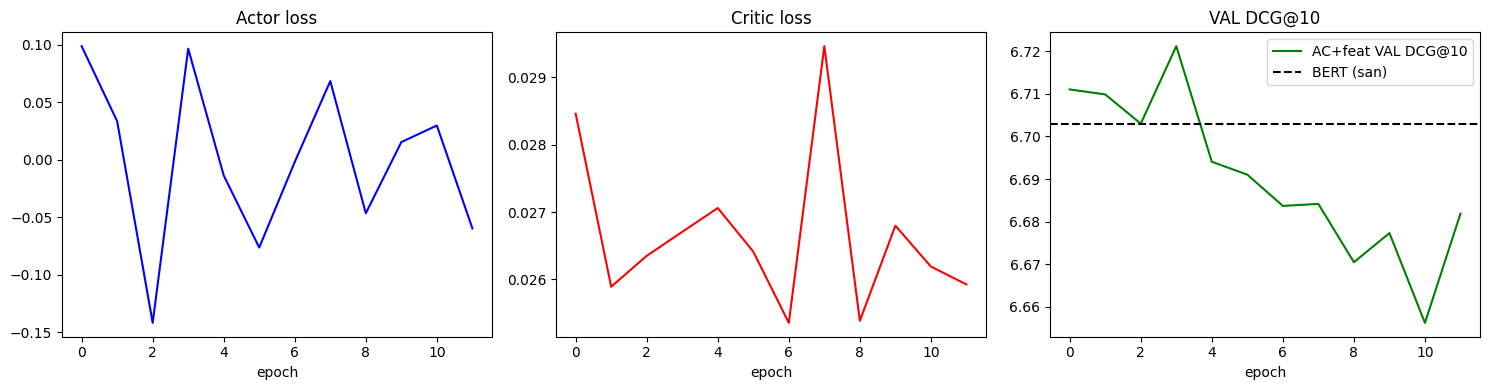

In [7]:
fig,ax=plt.subplots(1,3,figsize=(15,4))
ax[0].plot(hist["actor"],color="blue"); ax[0].set_title("Actor loss"); ax[0].set_xlabel("epoch")
ax[1].plot(hist["critic"],color="red"); ax[1].set_title("Critic loss"); ax[1].set_xlabel("epoch")
ax[2].plot(hist["val_dcg10"],color="green",label="AC+feat VAL DCG@10"); ax[2].axhline(base,ls="--",color="black",label="BERT (san)")
ax[2].set_title("VAL DCG@10"); ax[2].set_xlabel("epoch"); ax[2].legend()
plt.tight_layout(); plt.show()

## 6. Eval: BERT vs BERT+AC  (DCG/NDCG/Recall + ILD@10 + Coverage + Novelty)

In [8]:
rb,rl=rank_bert(bert,users,target="test",K=20); res_bert=metrics_full(rb,rl,GENRE_np,POPPROB_np)
ra,rl2=rank_ac(bert,actor,users,target="test",topN=50,K=20); res_ac=metrics_full(ra,rl2,GENRE_np,POPPROB_np)
results={"data_stats":stats,"BERT (short-term)":res_bert,"BERT + AC rerank (+features, diversity)":res_ac}
json.dump(results, open(os.path.join(HERE,"results_feat.json"),"w"), ensure_ascii=False, indent=2)
COLS=["DCG@10","NDCG@10","Recall@10","ILD@10","Coverage@10","Novelty@10"]
print(f"{'Model':<40}"+"".join(f"{c:>13}" for c in COLS)); print("-"*(40+13*len(COLS)))
for name,m in [("BERT (short-term)",res_bert),("BERT+AC (+features, diversity)",res_ac)]:
    print(f"{name:<40}"+"".join(f"{m[c]:>13.4f}" for c in COLS))

Model                                          DCG@10      NDCG@10    Recall@10       ILD@10  Coverage@10   Novelty@10
----------------------------------------------------------------------------------------------------------------------
BERT (short-term)                              6.8379       0.0613       0.0348       0.6660       0.0135       8.4265
BERT+AC (+features, diversity)                 6.8571       0.0615       0.0350       0.6700       0.0135       8.4281
